# Kaggle Setup and Dataset Download

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files

print("Upload your kaggle.json API token (from kaggle.com -> Account -> Create New API Token)")
uploaded = files.upload()

import os
os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json


Upload your kaggle.json API token (from kaggle.com -> Account -> Create New API Token)


Saving kaggle.json to kaggle.json


In [3]:
!kaggle datasets download -d pkdarabi/diagnosis-of-diabetic-retinopathy

Dataset URL: https://www.kaggle.com/datasets/pkdarabi/diagnosis-of-diabetic-retinopathy
License(s): MIT
100% 30.1M/30.1M [00:00<00:00, 123MB/s]



In [4]:
import zipfile

with zipfile.ZipFile("/content/diagnosis-of-diabetic-retinopathy.zip", "r") as zip_ref:
    zip_ref.extractall("/content/Diabetic_Retinopathy_Dataset")

print("Extraction complete.")


Extraction complete.


# Importing Libraries

In [5]:
!pip -q install kagglehub seaborn scikit-learn pillow statsmodels

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_fscore_support
)

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configuration

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 32

EPOCHS = 25
FINE_TUNE_EPOCHS = 20

BACKBONE_NAME = "DenseNet121"

OUTPUT_DIR = "/content/diabetic_retinopathy_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATASET_ROOT = "/content/Diabetic_Retinopathy_Dataset"

print("Backbone:", BACKBONE_NAME)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Output:", OUTPUT_DIR)


Backbone: DenseNet121
Image size: 224
Batch size: 32
Output: /content/diabetic_retinopathy_outputs


# Dataset Discovery

In [7]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

TRAIN_NAMES = {"train", "training"}
VAL_NAMES = {"val", "valid", "validation"}
TEST_NAMES = {"test", "testing"}


def count_images(folder):
    return sum(
        1 for f in os.listdir(folder)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    )


def find_split_roots(root):
    """Find every folder that directly contains train/valid/test subfolders,
    each of which contains class subfolders. Returns a list of dicts with
    the resolved split folder paths, discovered classes, and a fingerprint
    (per-split, per-class image counts) used to detect duplicate copies.
    """
    candidates = []

    for current_root, dirs, _ in os.walk(root):
        lower_dirs = {d.lower(): d for d in dirs}

        train_name = next((lower_dirs[n] for n in TRAIN_NAMES if n in lower_dirs), None)
        val_name = next((lower_dirs[n] for n in VAL_NAMES if n in lower_dirs), None)
        test_name = next((lower_dirs[n] for n in TEST_NAMES if n in lower_dirs), None)

        if not (train_name and val_name and test_name):
            continue

        split_paths = {
            "train": os.path.join(current_root, train_name),
            "valid": os.path.join(current_root, val_name),
            "test": os.path.join(current_root, test_name),
        }

        train_classes = sorted(
            d for d in os.listdir(split_paths["train"])
            if os.path.isdir(os.path.join(split_paths["train"], d))
        )

        if not train_classes:
            continue

        fingerprint = []
        valid_candidate = True

        for split_name, split_path in split_paths.items():
            for class_name in train_classes:
                class_dir = os.path.join(split_path, class_name)
                if not os.path.isdir(class_dir):
                    valid_candidate = False
                    break
                fingerprint.append((split_name, class_name, count_images(class_dir)))
            if not valid_candidate:
                break

        if not valid_candidate:
            continue

        candidates.append({
            "root": current_root,
            "split_paths": split_paths,
            "class_names": train_classes,
            "fingerprint": tuple(fingerprint),
        })

    return candidates


candidates = find_split_roots(DATASET_ROOT)

print(f"Found {len(candidates)} candidate dataset root(s):")
for c in candidates:
    print(" -", c["root"], "| classes:", c["class_names"])

seen_fingerprints = {}
unique_candidates = []

for c in candidates:
    if c["fingerprint"] in seen_fingerprints:
        print(f"\nSkipping duplicate copy: {c['root']}")
        print(f"  (identical to: {seen_fingerprints[c['fingerprint']]})")
        continue
    seen_fingerprints[c["fingerprint"]] = c["root"]
    unique_candidates.append(c)

assert len(unique_candidates) >= 1, "Could not find a usable train/valid/test dataset root."

if len(unique_candidates) > 1:
    print(
        "\nWarning: multiple *different* dataset roots were found "
        "(different image counts). Using the first one below - "
        "inspect `unique_candidates` if this looks wrong."
    )

chosen = unique_candidates[0]
SPLIT_PATHS = chosen["split_paths"]
CLASS_NAMES = chosen["class_names"]
NUM_CLASSES = len(CLASS_NAMES)

print("\nUsing dataset root:", chosen["root"])
print("Classes:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)


Found 2 candidate dataset root(s):
 - /content/Diabetic_Retinopathy_Dataset/Diagnosis of Diabetic Retinopathy | classes: ['DR', 'No_DR']
 - /content/Diabetic_Retinopathy_Dataset/retino | classes: ['DR', 'No_DR']

Skipping duplicate copy: /content/Diabetic_Retinopathy_Dataset/retino
  (identical to: /content/Diabetic_Retinopathy_Dataset/Diagnosis of Diabetic Retinopathy)

Using dataset root: /content/Diabetic_Retinopathy_Dataset/Diagnosis of Diabetic Retinopathy
Classes: ['DR', 'No_DR']
Number of classes: 2


## Data Collection and Class Distribution

In [9]:
def build_split_dataframe(split_path, class_names):
    records = []

    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(split_path, class_name)

        for filename in os.listdir(class_dir):
            if filename.lower().endswith(IMAGE_EXTENSIONS):
                records.append({
                    "filepath": os.path.join(class_dir, filename),
                    "label": label,
                    "class": class_name
                })

    return pd.DataFrame(records).reset_index(drop=True)


train_df = build_split_dataframe(SPLIT_PATHS["train"], CLASS_NAMES)
validation_df = build_split_dataframe(SPLIT_PATHS["valid"], CLASS_NAMES)
test_df = build_split_dataframe(SPLIT_PATHS["test"], CLASS_NAMES)


df = pd.concat([train_df, validation_df, test_df], ignore_index=True)

print("Training:", len(train_df))
print("Validation:", len(validation_df))
print("Testing:", len(test_df))
print("Total images (train+valid+test):", len(df))

display(df.head())

print("\nOverall class distribution:")
display(df["class"].value_counts().rename_axis("class").reset_index(name="count"))

print("\nTraining distribution:")
display(train_df["class"].value_counts())

print("\nValidation distribution:")
display(validation_df["class"].value_counts())

print("\nTesting distribution:")
display(test_df["class"].value_counts())


Training: 2076
Validation: 531
Testing: 231
Total images (train+valid+test): 2838


,filepath,label,class
0,/content/Diabetic_Retinopathy_Dataset/Diagnosi...,0,DR
1,/content/Diabetic_Retinopathy_Dataset/Diagnosi...,0,DR
2,/content/Diabetic_Retinopathy_Dataset/Diagnosi...,0,DR
3,/content/Diabetic_Retinopathy_Dataset/Diagnosi...,0,DR
4,/content/Diabetic_Retinopathy_Dataset/Diagnosi...,0,DR



Overall class distribution:


,class,count
0,No_DR,1430
1,DR,1408



Training distribution:


,count
class,
DR,1050
No_DR,1026



Validation distribution:


,count
class,
No_DR,286
DR,245



Testing distribution:


,count
class,
No_DR,118
DR,113


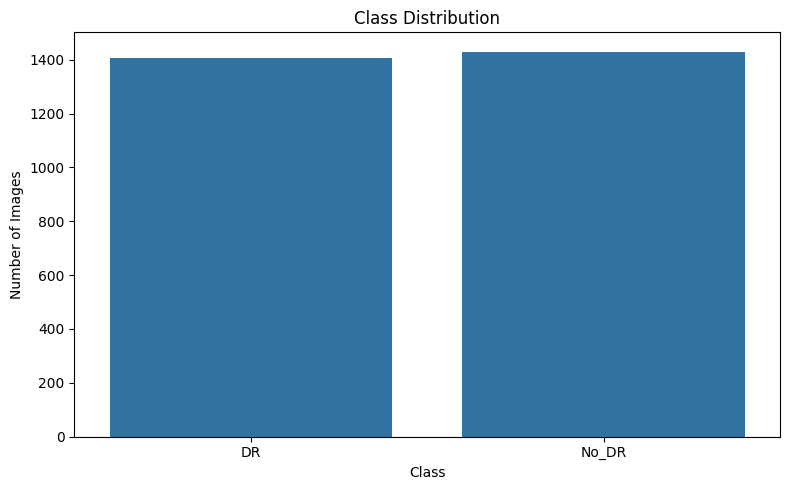

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="class", order=CLASS_NAMES)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_distribution.png", dpi=300)
plt.show()


## Sample Images

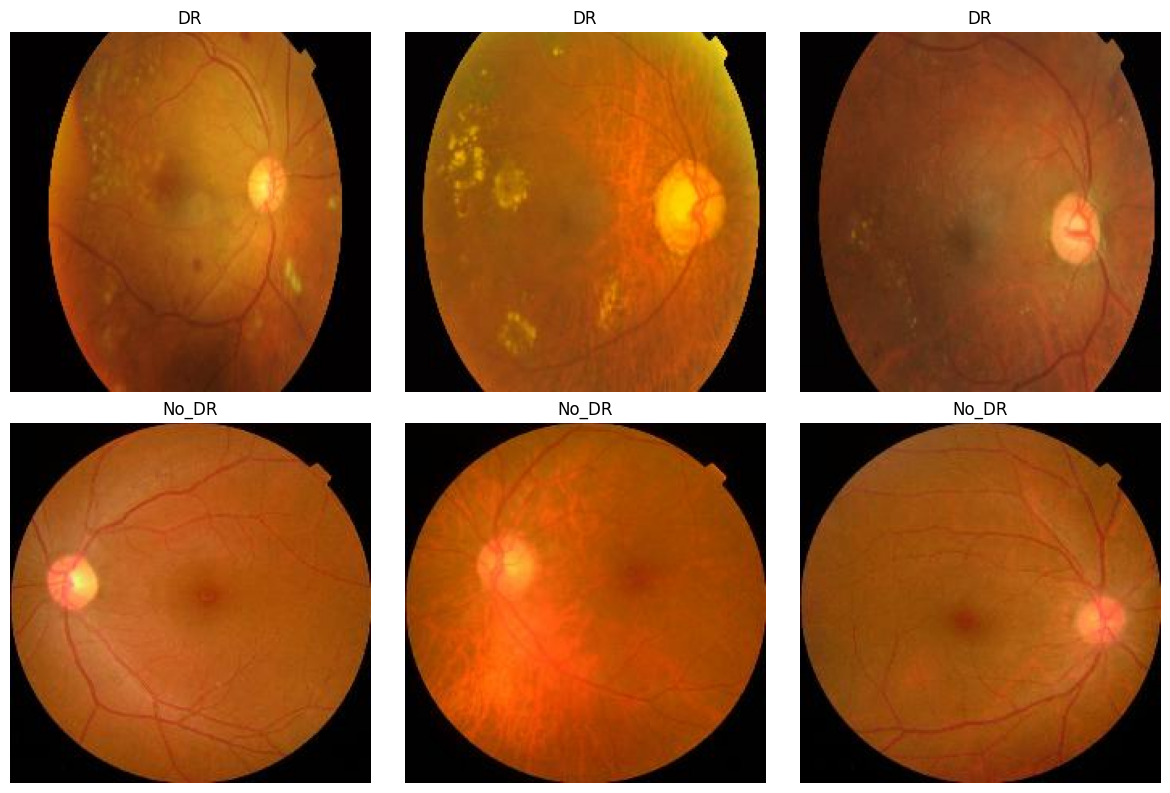

In [11]:
n_cols = 3
fig, axes = plt.subplots(NUM_CLASSES, n_cols, figsize=(12, 4 * NUM_CLASSES))

if NUM_CLASSES == 1:
    axes = np.array([axes])

for row, class_name in enumerate(CLASS_NAMES):

    class_df = df[df["class"] == class_name]

    samples = class_df.sample(
        min(n_cols, len(class_df)),
        random_state=SEED
    )

    for col, (_, sample) in enumerate(samples.iterrows()):

        image = Image.open(sample["filepath"]).convert("RGB")

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

    for col in range(len(samples), n_cols):
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/sample_images.png", dpi=300)
plt.show()


## Feature Engineering for EDA, Scaling and Feature Selection

In [12]:
def extract_image_features(path):

    image = Image.open(path).convert("L")
    image = image.resize((128, 128))

    arr = np.asarray(image, dtype=np.float32) / 255.0
    pixels = arr.flatten()

    return {
        "mean_intensity": np.mean(pixels),
        "std_intensity": np.std(pixels),
        "min_intensity": np.min(pixels),
        "max_intensity": np.max(pixels),
        "median_intensity": np.median(pixels),
        "q25_intensity": np.percentile(pixels, 25),
        "q75_intensity": np.percentile(pixels, 75),
        "dark_pixel_ratio": np.mean(pixels < 0.20),
        "bright_pixel_ratio": np.mean(pixels > 0.80),
        "edge_strength": np.mean(np.abs(np.diff(arr, axis=0))),
        "horizontal_variance": np.var(np.mean(arr, axis=0)),
        "vertical_variance": np.var(np.mean(arr, axis=1))
    }

SAMPLE_SIZE_FOR_EDA = min(len(df), 1500)
eda_df = df.sample(SAMPLE_SIZE_FOR_EDA, random_state=SEED).reset_index(drop=True)

feature_records = []

for _, row in eda_df.iterrows():

    features = extract_image_features(row["filepath"])
    features["class"] = row["class"]
    features["label"] = row["label"]

    feature_records.append(features)

features_df = pd.DataFrame(feature_records)

print("Engineered feature shape:", features_df.shape)
display(features_df.head())


Engineered feature shape: (1500, 14)


,mean_intensity,std_intensity,min_intensity,max_intensity,median_intensity,q25_intensity,q75_intensity,dark_pixel_ratio,bright_pixel_ratio,edge_strength,horizontal_variance,vertical_variance,class,label
0,0.243165,0.112338,0.000000,0.572549,0.278431,0.223529,0.313726,0.176880,0.000000,0.007476,0.006558,0.001504,DR,0
1,0.146813,0.092379,0.000000,0.580392,0.172549,0.039216,0.207843,0.703430,0.000000,0.005806,0.005856,0.001242,DR,0
2,0.338933,0.177125,0.000000,0.811765,0.411765,0.364706,0.443137,0.212646,0.000244,0.011989,0.011130,0.010116,No_DR,1
3,0.172546,0.061894,0.011765,0.494118,0.188235,0.149020,0.211765,0.623779,0.000000,0.004250,0.001978,0.000931,DR,0
4,0.291019,0.143425,0.007843,0.996078,0.286275,0.192157,0.396078,0.263733,0.003235,0.009922,0.010830,0.004287,No_DR,1


# Histograms

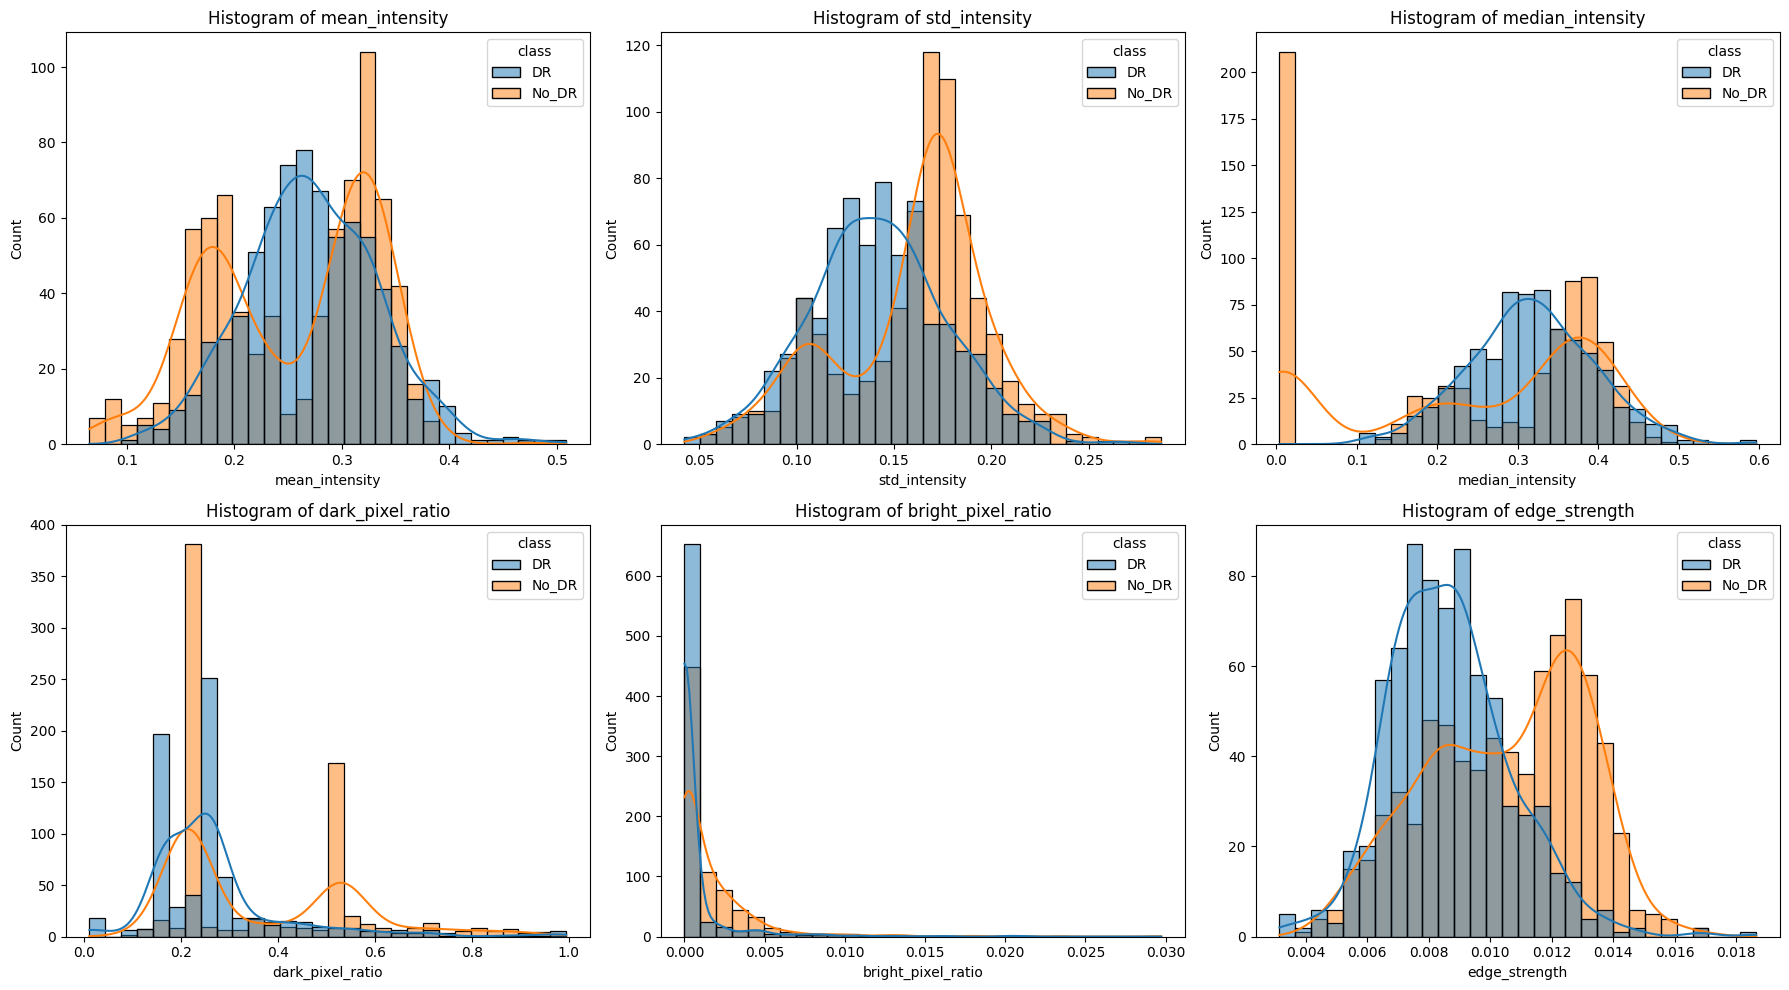

In [13]:
numeric_features = [
    "mean_intensity",
    "std_intensity",
    "median_intensity",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_strength"
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(
        data=features_df,
        x=feature,
        hue="class",
        kde=True,
        bins=30,
        ax=axes[i]
    )
    axes[i].set_title(f"Histogram of {feature}")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/all_histograms.png", dpi=300)
plt.show()


# Box Plots

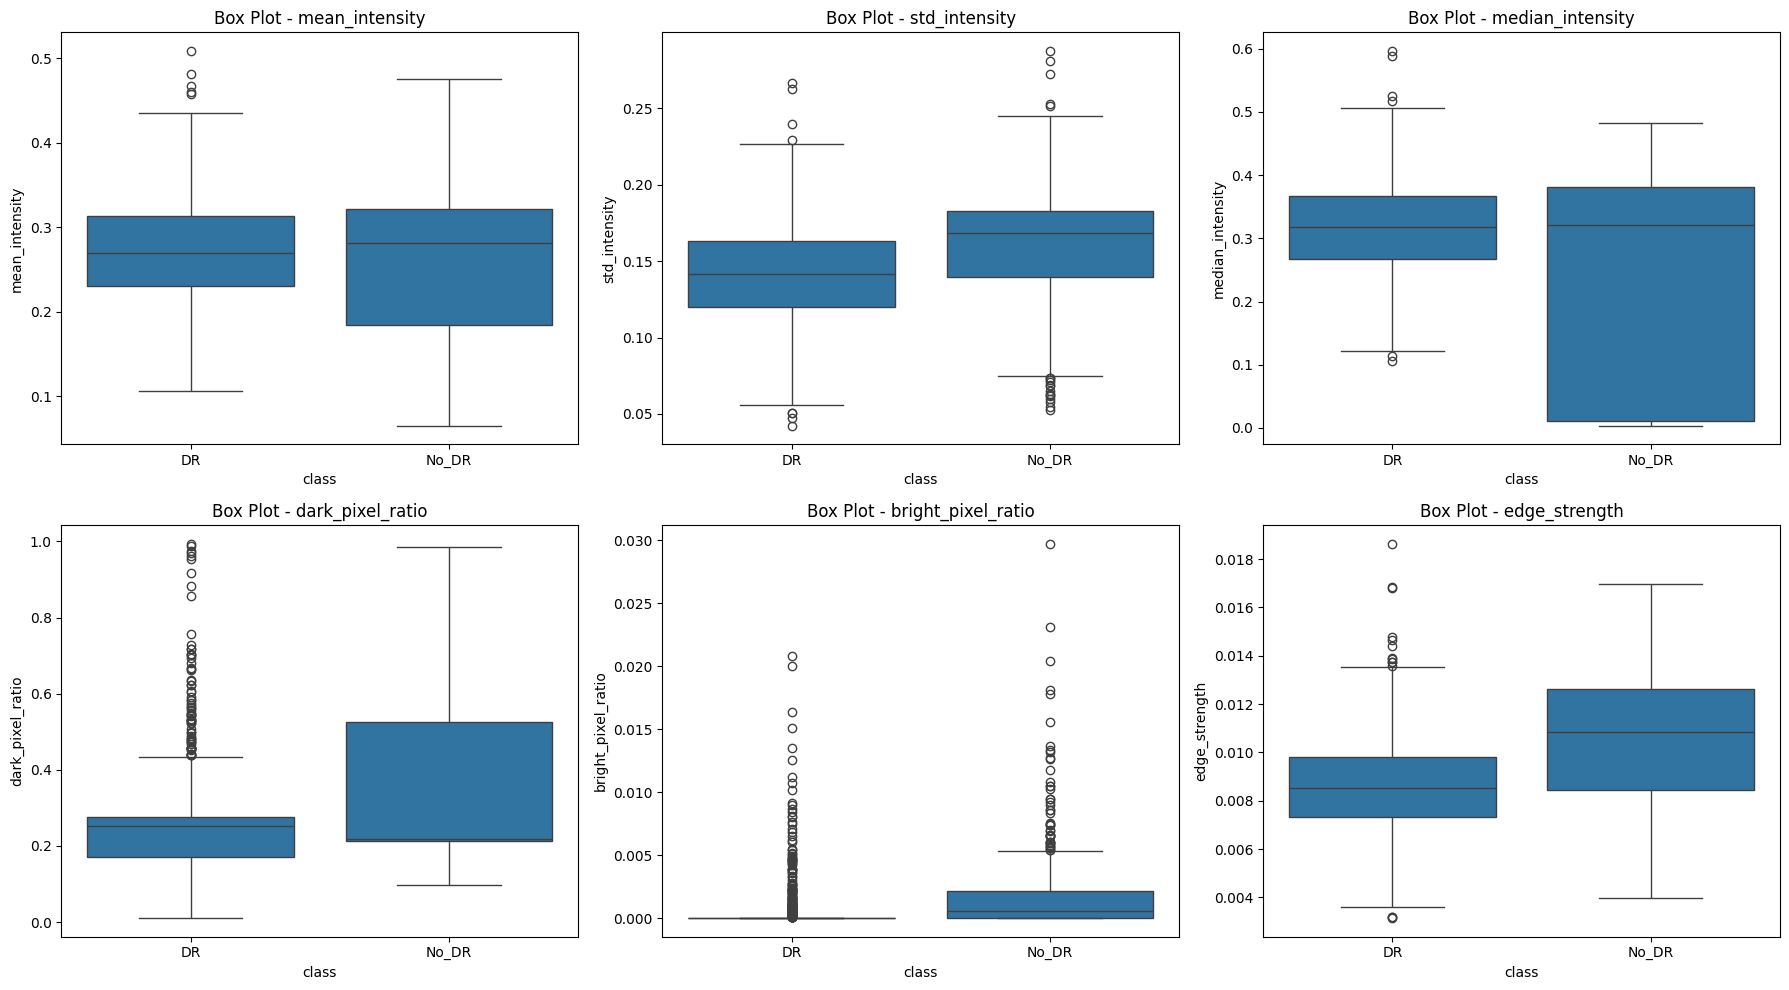

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(
        data=features_df,
        x="class",
        y=feature,
        order=CLASS_NAMES,
        ax=axes[i]
    )
    axes[i].set_title(f"Box Plot - {feature}")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/all_boxplots.png", dpi=300)
plt.show()


# Scatter Plot

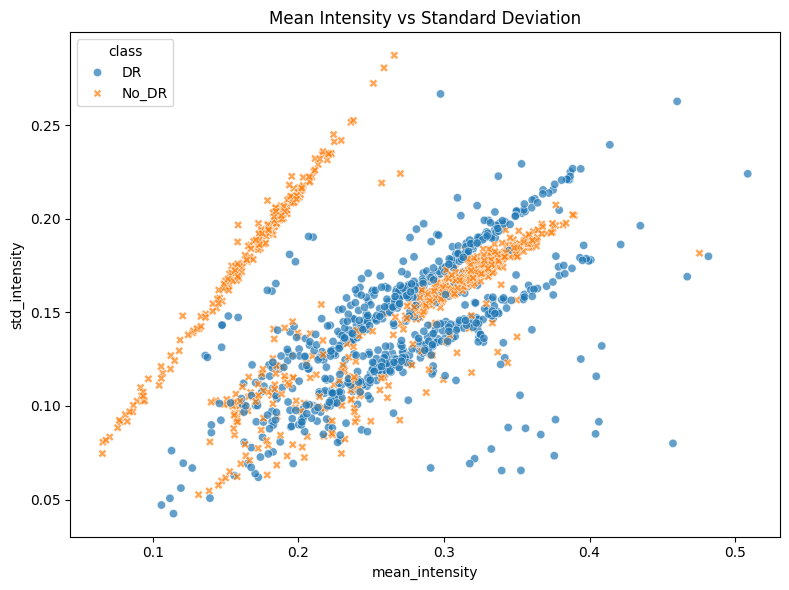

In [15]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=features_df,
    x="mean_intensity",
    y="std_intensity",
    hue="class",
    style="class",
    alpha=0.7
)

plt.title("Mean Intensity vs Standard Deviation")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/scatter_plot.png", dpi=300)
plt.show()


# Regression Plot

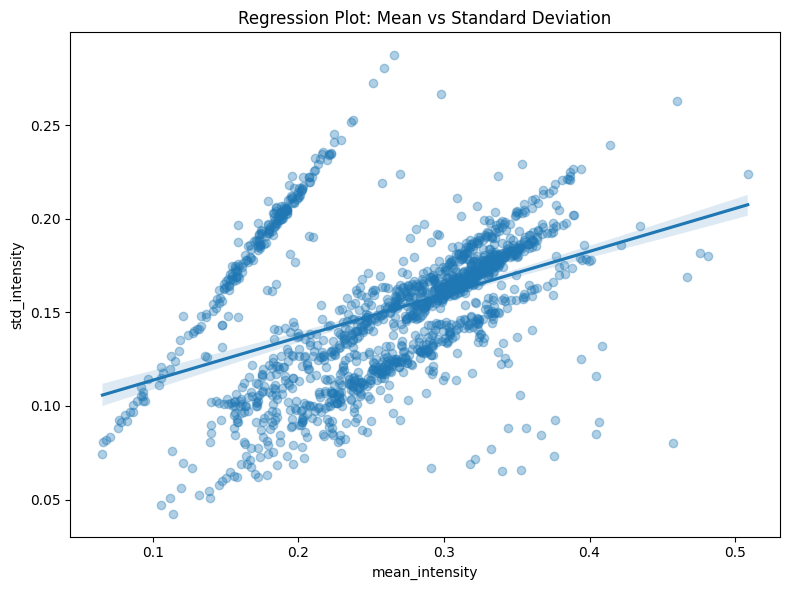

In [16]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=features_df,
    x="mean_intensity",
    y="std_intensity",
    scatter_kws={"alpha": 0.35}
)

plt.title("Regression Plot: Mean vs Standard Deviation")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/regression_plot.png", dpi=300)
plt.show()


# Heatmap

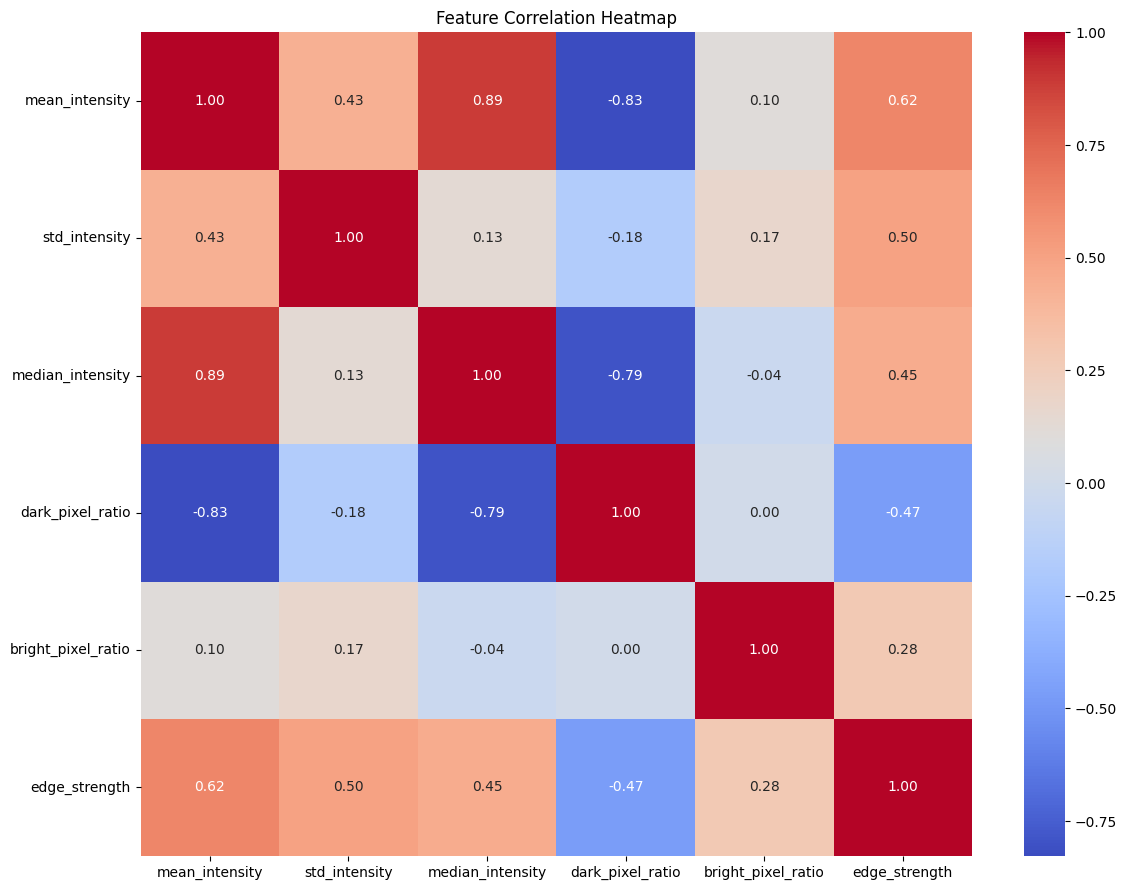

In [17]:
plt.figure(figsize=(12, 9))

correlation_matrix = features_df[numeric_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_correlation_heatmap.png", dpi=300)
plt.show()


# Pairplot

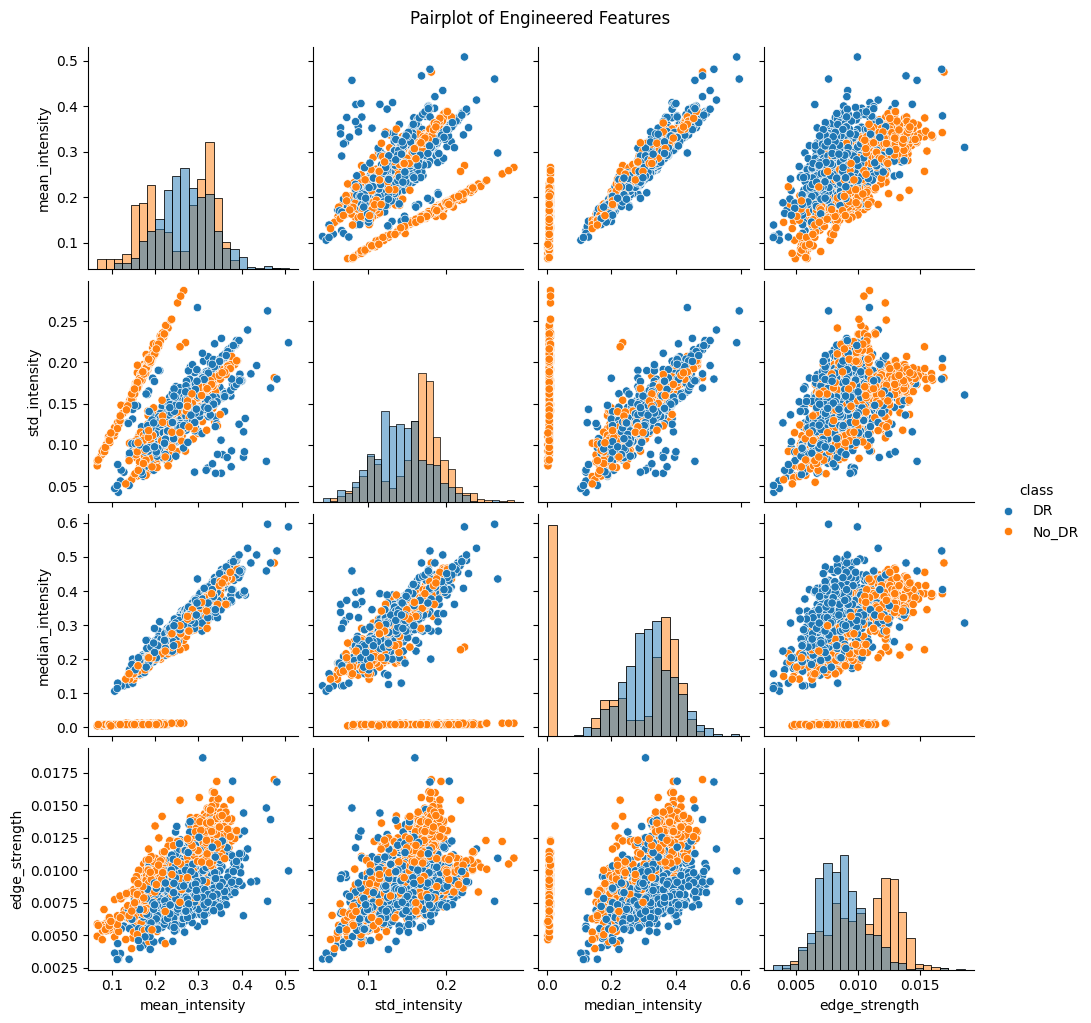

In [18]:
pairplot_features = [
    "mean_intensity",
    "std_intensity",
    "median_intensity",
    "edge_strength"
]

g = sns.pairplot(
    features_df[pairplot_features + ["class"]],
    hue="class",
    diag_kind="hist"
)

g.fig.suptitle(
    "Pairplot of Engineered Features",
    y=1.02
)

g.savefig(f"{OUTPUT_DIR}/pairplot.png", dpi=300)
plt.show()


## Scaling and Feature Selection

In [19]:
X_features = features_df[numeric_features]
y_features = features_df["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print("Scaled feature matrix:", X_scaled.shape)

k = min(5, X_scaled.shape[1])

selector = SelectKBest(
    score_func=f_classif,
    k=k
)

X_selected = selector.fit_transform(
    X_scaled,
    y_features
)

selected_feature_names = [
    feature
    for feature, selected
    in zip(numeric_features, selector.get_support())
    if selected
]

feature_scores = pd.DataFrame({
    "feature": numeric_features,
    "f_score": selector.scores_,
    "p_value": selector.pvalues_
}).sort_values("f_score", ascending=False)

print("Selected features:", selected_feature_names)
display(feature_scores)


Scaled feature matrix: (1500, 6)
Selected features: ['std_intensity', 'median_intensity', 'dark_pixel_ratio', 'bright_pixel_ratio', 'edge_strength']


,feature,f_score,p_value
5,edge_strength,242.790449,7.573978e-51
2,median_intensity,132.342968,2.077683e-29
3,dark_pixel_ratio,128.713565,1.116841e-28
1,std_intensity,94.902760,8.723685e-22
4,bright_pixel_ratio,60.568106,1.315832e-14
0,mean_intensity,22.095536,2.832424e-06


In [20]:
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["label"]
)

class_weights = {i: w for i, w in enumerate(class_weight_values)}
print("Class weights (to counter class imbalance):", class_weights)


Class weights (to counter class imbalance): {0: np.float64(0.9885714285714285), 1: np.float64(1.0116959064327486)}


## Data Augmentation and Generators

In [21]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    shear_range=0.05,
    brightness_range=(0.85, 1.15),
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)

validation_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()


train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    classes=CLASS_NAMES,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_generator = validation_datagen.flow_from_dataframe(
    dataframe=validation_df,
    x_col="filepath",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    classes=CLASS_NAMES,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    classes=CLASS_NAMES,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Generator class indices:")
print(train_generator.class_indices)


Found 2076 validated image filenames belonging to 2 classes.
Found 531 validated image filenames belonging to 2 classes.
Found 231 validated image filenames belonging to 2 classes.
Generator class indices:
{'DR': 0, 'No_DR': 1}


## Transfer-Learning Backbone



In [22]:
def get_backbone(name):

    name = name.lower()
    input_shape = (IMG_SIZE, IMG_SIZE, 3)

    if name == "densenet121":
        backbone = DenseNet121(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )
        preprocess = densenet_preprocess

    else:
        raise ValueError("This notebook only supports DenseNet121.")

    return backbone, preprocess


backbone, preprocess_function = get_backbone(BACKBONE_NAME)

print("Loaded:", BACKBONE_NAME)
print("Number of backbone layers:", len(backbone.layers))


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loaded: DenseNet121
Number of backbone layers: 427


## CNN Architecture

In [23]:
backbone.trainable = False

inputs = layers.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3),
    name="input_image"
)

x = layers.Lambda(
    preprocess_function,
    name="preprocessing"
)(inputs)

x = backbone(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dense(
    256,
    activation="relu",
    name="dense_feature_layer"
)(x)

x = layers.BatchNormalization(
    name="batch_normalization"
)(x)

x = layers.Dropout(0.40)(x)

x = layers.Dense(
    64,
    activation="relu",
    name="dense_feature_layer_2"
)(x)

x = layers.Dropout(0.25)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classification_output"
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessing (Lambda)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_feature_layer (Dense)     │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_feature_layer_2 (Dense)   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_output (Dense)   │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,317,506 (27.91 MB)

 Trainable params: 279,490 (1.07 MB)

 Non-trainable params: 7,038,016 (26.85 MB)

## Early Stopping, Checkpointing and Training (Frozen Backbone)

In [24]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath=os.path.join(OUTPUT_DIR, "best_dr_model.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)


history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ]
)


Epoch 1/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - accuracy: 0.8508 - loss: 0.3813
Epoch 1: val_accuracy improved from None to 0.95292, saving model to /content/diabetic_retinopathy_outputs/best_dr_model.keras

Epoch 1: finished saving model to /content/diabetic_retinopathy_outputs/best_dr_model.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.8998 - loss: 0.2601 - val_accuracy: 0.9529 - val_loss: 0.1515 - learning_rate: 0.0010
Epoch 2/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.9424 - loss: 0.1767
Epoch 2: val_accuracy did not improve from 0.95292
65/65 ━━━━━━━━━━━━━━━━━━━━ 34s 529ms/step - accuracy: 0.9403 - loss: 0.1754 - val_accuracy: 0.9454 - val_loss: 0.1298 - learning_rate: 0.0010
Epoch 3/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9372 - loss: 0.1675
Epoch 3: val_accuracy improved from 0.95292 to 0.96234, saving model to /content/diabetic_retinopathy_outputs/best_dr_model.keras

Epoch 3: finished saving model to /content/diabetic_retino

## Fine-Tuning

In [25]:
backbone.trainable = True

fine_tune_from = int(len(backbone.layers) * 0.70)

for layer in backbone.layers[:fine_tune_from]:
    layer.trainable = False

for layer in backbone.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ]
)


Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 788ms/step - accuracy: 0.9464 - loss: 0.1460
Epoch 1: val_accuracy did not improve from 0.97175
65/65 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.9523 - loss: 0.1318 - val_accuracy: 0.9661 - val_loss: 0.0840 - learning_rate: 1.0000e-05
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9562 - loss: 0.1177
Epoch 2: val_accuracy did not improve from 0.97175
65/65 ━━━━━━━━━━━━━━━━━━━━ 32s 489ms/step - accuracy: 0.9605 - loss: 0.1174 - val_accuracy: 0.9642 - val_loss: 0.0886 - learning_rate: 1.0000e-05
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.9557 - loss: 0.1150
Epoch 3: val_accuracy did not improve from 0.97175
65/65 ━━━━━━━━━━━━━━━━━━━━ 34s 517ms/step - accuracy: 0.9600 - loss: 0.1119 - val_accuracy: 0.9718 - val_loss: 0.0826 - learning_rate: 1.0000e-05
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9594 - loss: 0.1296
Epoch 4: val_accuracy did not improve from 0.97175
65/65 ━━━━━━━━━━

# Accuracy Curve

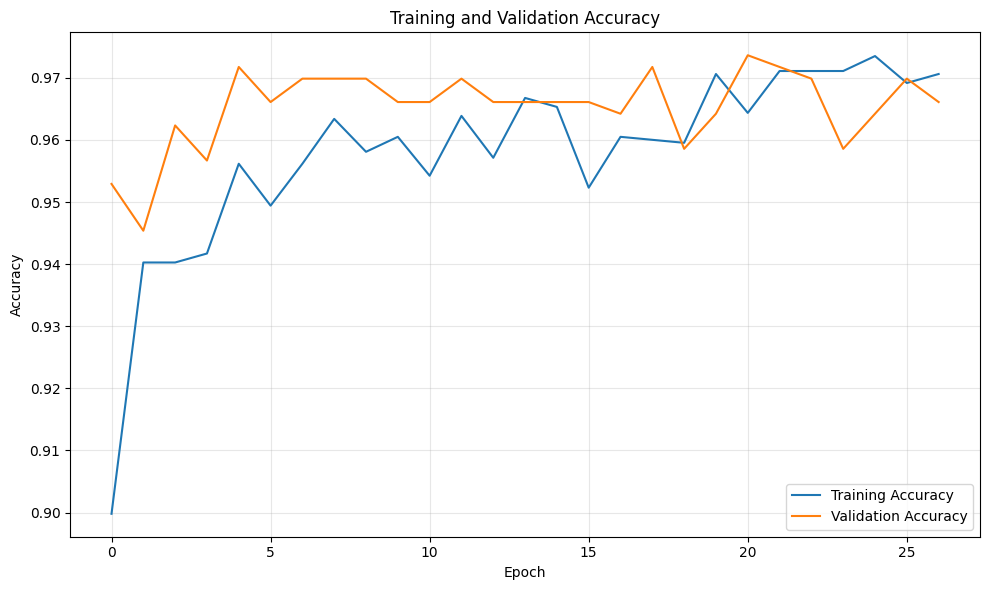

Final training accuracy: 0.9706165790557861
Final validation accuracy: 0.9661017060279846


In [26]:
acc = history.history["accuracy"] + fine_tune_history.history["accuracy"]
val_acc = history.history["val_accuracy"] + fine_tune_history.history["val_accuracy"]

plt.figure(figsize=(10, 6))

plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/accuracy_curve.png", dpi=300)
plt.show()

print("Final training accuracy:", acc[-1])
print("Final validation accuracy:", val_acc[-1])


# Loss Curve

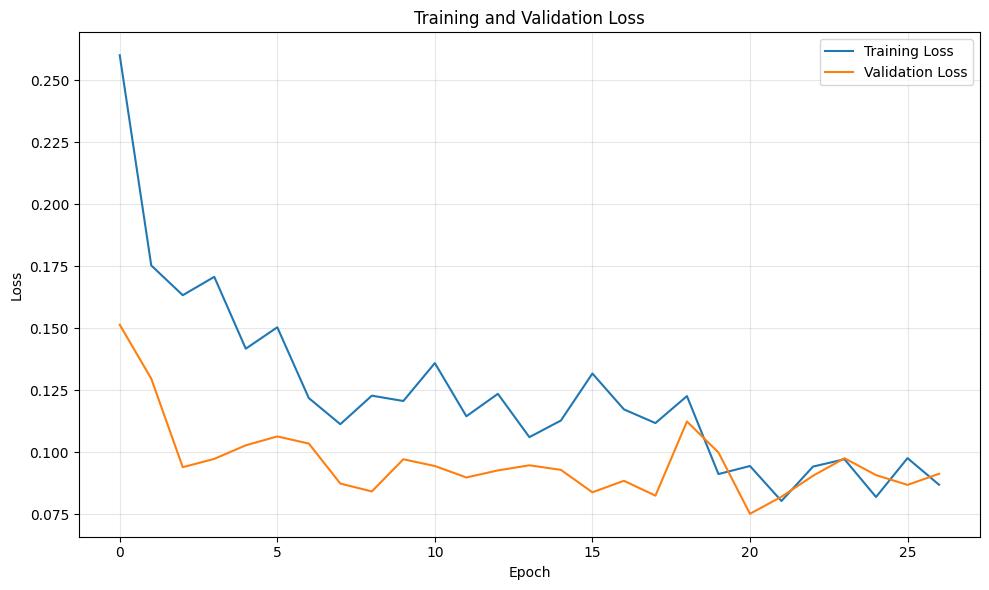

In [27]:
loss = history.history["loss"] + fine_tune_history.history["loss"]
val_loss = history.history["val_loss"] + fine_tune_history.history["val_loss"]

plt.figure(figsize=(10, 6))

plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/loss_curve.png", dpi=300)
plt.show()


## Test Set Evaluation

In [28]:
_, preprocess_function = get_backbone(BACKBONE_NAME)

custom_objects = {
    'preprocess_input': preprocess_function
}

best_model_path = os.path.join(OUTPUT_DIR, "best_dr_model.keras")

if os.path.exists(best_model_path):
    model = tf.keras.models.load_model(best_model_path, custom_objects=custom_objects)
    print("Best model loaded.")

test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

test_generator.reset()

probabilities = model.predict(
    test_generator,
    verbose=1
)

predicted_labels = np.argmax(probabilities, axis=1)
true_labels = test_generator.classes


Best model loaded.
8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.9827 - loss: 0.0762
Test loss: 0.07621396332979202
Test accuracy: 0.9826839566230774
8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step


## Classification Report and Per-Class Metrics

In [29]:
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=CLASS_NAMES,
    digits=4
)

print(report)

with open(f"{OUTPUT_DIR}/classification_report.txt", "w") as f:
    f.write(report)


precision, recall, f1, support = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    average=None,
    labels=range(NUM_CLASSES)
)

metrics_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "Support": support
})

display(metrics_df)


              precision    recall  f1-score   support

          DR     0.9910    0.9735    0.9821       113
       No_DR     0.9750    0.9915    0.9832       118

    accuracy                         0.9827       231
   macro avg     0.9830    0.9825    0.9827       231
weighted avg     0.9828    0.9827    0.9827       231



,Class,Precision,Recall,F1 Score,Support
0,DR,0.990991,0.973451,0.982143,113
1,No_DR,0.975000,0.991525,0.983193,118


# Confusion Matrix

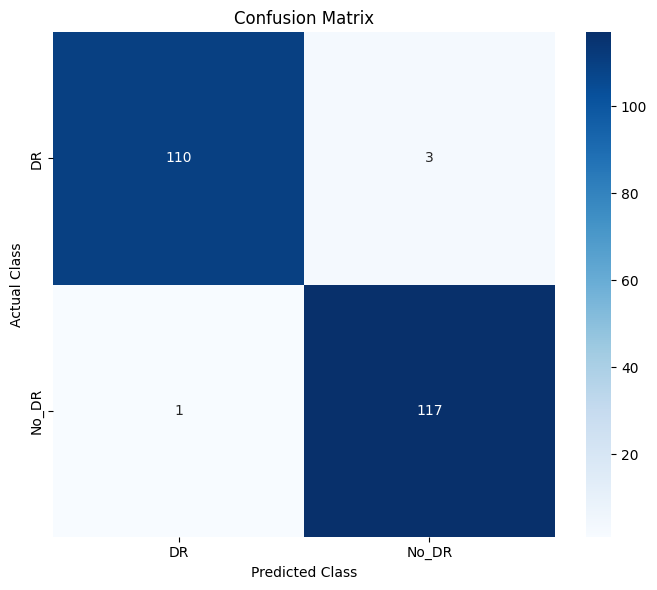

In [30]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=300)
plt.show()


# Normalized Confusion Matrix

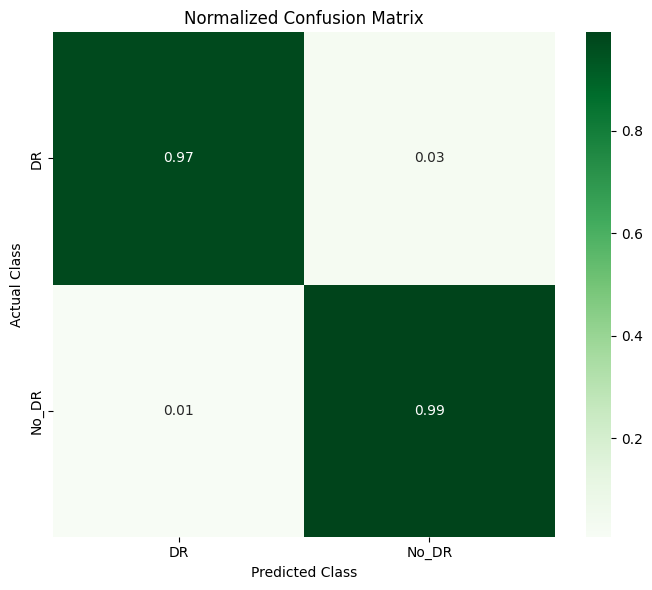

In [31]:
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/normalized_confusion_matrix.png", dpi=300)
plt.show()


## ROC Curve and AUC

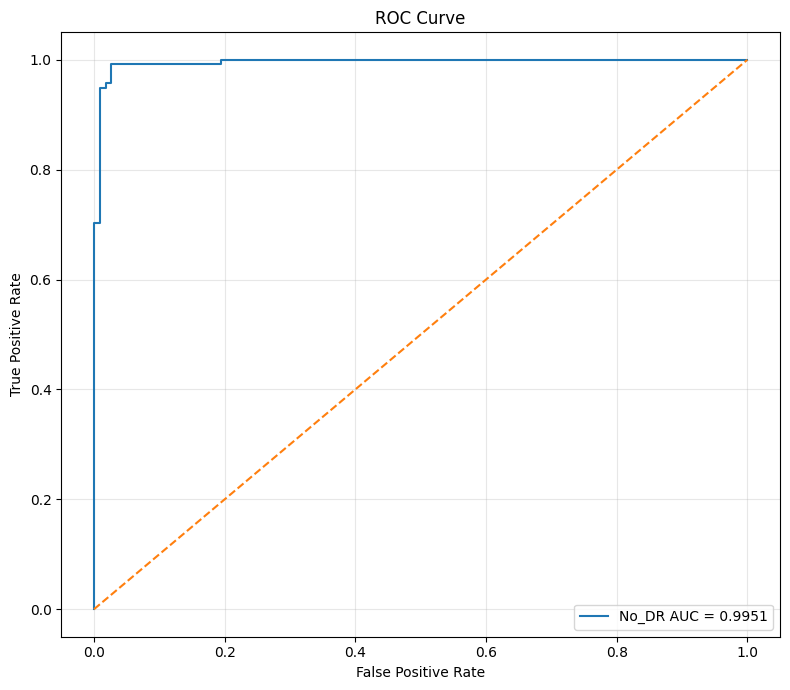

ROC-AUC: 0.9951252437378131


In [33]:
plt.figure(figsize=(8, 7))

if NUM_CLASSES == 2:

    positive_class_index = 1

    fpr, tpr, _ = roc_curve(
        true_labels,
        probabilities[:, positive_class_index]
    )
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[positive_class_index]} AUC = {roc_auc:.4f}")

    macro_auc = roc_auc

else:
    true_labels_binary = label_binarize(true_labels, classes=np.arange(NUM_CLASSES))

    for i, class_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(true_labels_binary[:, i], probabilities[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} AUC = {roc_auc:.4f}")

    macro_auc = roc_auc_score(
        true_labels_binary,
        probabilities,
        multi_class="ovr",
        average="macro"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve.png", dpi=300)
plt.show()

print("ROC-AUC:", macro_auc)


## Error Analysis and Visualization

Number of incorrect predictions: 4


,filepath,actual,predicted,confidence
0,/content/Diabetic_Retinopathy_Dataset/Diagnosi...,DR,No_DR,0.989407
1,/content/Diabetic_Retinopathy_Dataset/Diagnosi...,DR,No_DR,0.816610
2,/content/Diabetic_Retinopathy_Dataset/Diagnosi...,DR,No_DR,0.811635
3,/content/Diabetic_Retinopathy_Dataset/Diagnosi...,No_DR,DR,0.993269


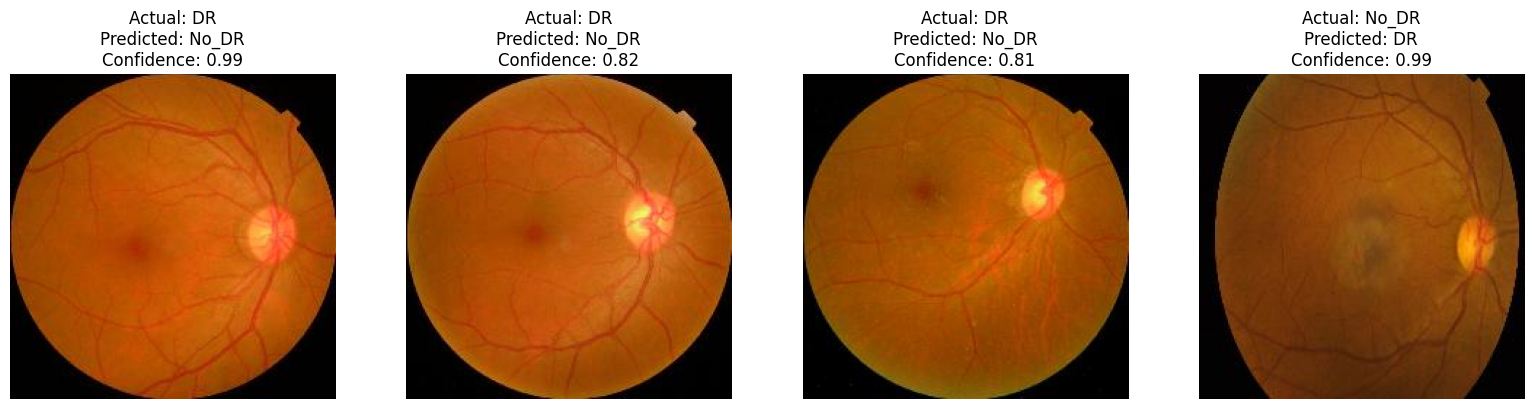

In [34]:
errors = []

for i in range(len(test_df)):

    actual = true_labels[i]
    predicted = predicted_labels[i]

    if actual != predicted:
        errors.append({
            "filepath": test_df.iloc[i]["filepath"],
            "actual": CLASS_NAMES[actual],
            "predicted": CLASS_NAMES[predicted],
            "confidence": probabilities[i][predicted]
        })

errors_df = pd.DataFrame(errors)

print("Number of incorrect predictions:", len(errors_df))
display(errors_df.head(20))


if len(errors_df) > 0:

    number_to_display = min(12, len(errors_df))
    samples = errors_df.head(number_to_display)

    columns = 4
    rows = int(np.ceil(number_to_display / columns))

    fig, axes = plt.subplots(rows, columns, figsize=(16, rows * 4))
    axes = np.array(axes).reshape(rows, columns)

    for i, (_, row) in enumerate(samples.iterrows()):

        image = Image.open(row["filepath"]).convert("RGB")

        r = i // columns
        c = i % columns

        axes[r, c].imshow(image)
        axes[r, c].set_title(
            f"Actual: {row['actual']}\n"
            f"Predicted: {row['predicted']}\n"
            f"Confidence: {row['confidence']:.2f}"
        )
        axes[r, c].axis("off")

    for i in range(number_to_display, rows * columns):
        r = i // columns
        c = i % columns
        axes[r, c].axis("off")

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/prediction_errors.png", dpi=300)
    plt.show()
else:
    print("No misclassified test images.")


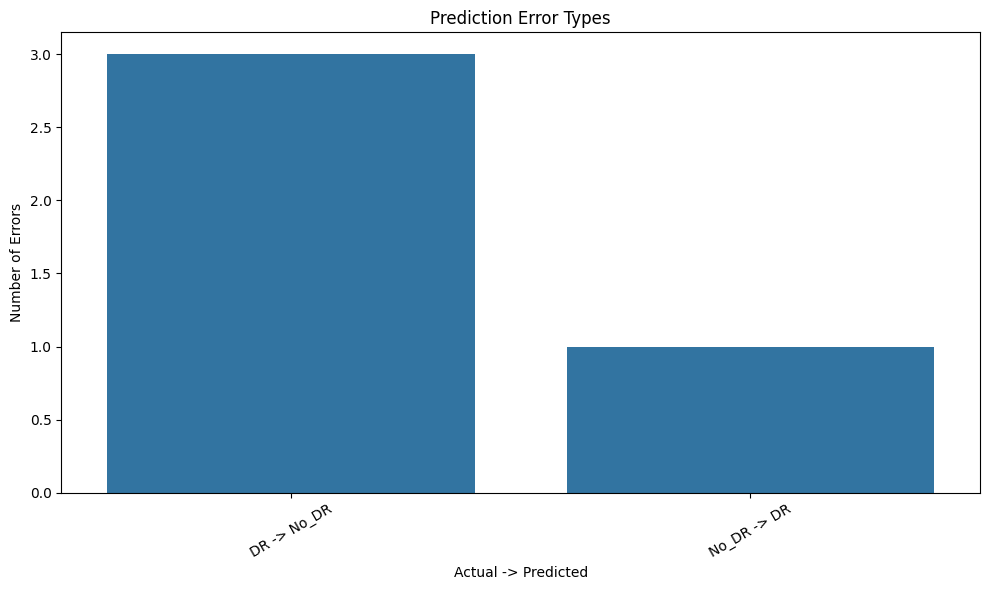

In [35]:
if len(errors_df) > 0:

    error_types = (
        errors_df
        .groupby(["actual", "predicted"])
        .size()
        .reset_index(name="count")
    )

    error_types["error_type"] = error_types["actual"] + " -> " + error_types["predicted"]

    plt.figure(figsize=(10, 6))

    sns.barplot(data=error_types, x="error_type", y="count")

    plt.title("Prediction Error Types")
    plt.xlabel("Actual -> Predicted")
    plt.ylabel("Number of Errors")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/error_types.png", dpi=300)
    plt.show()


## Prediction Confidence

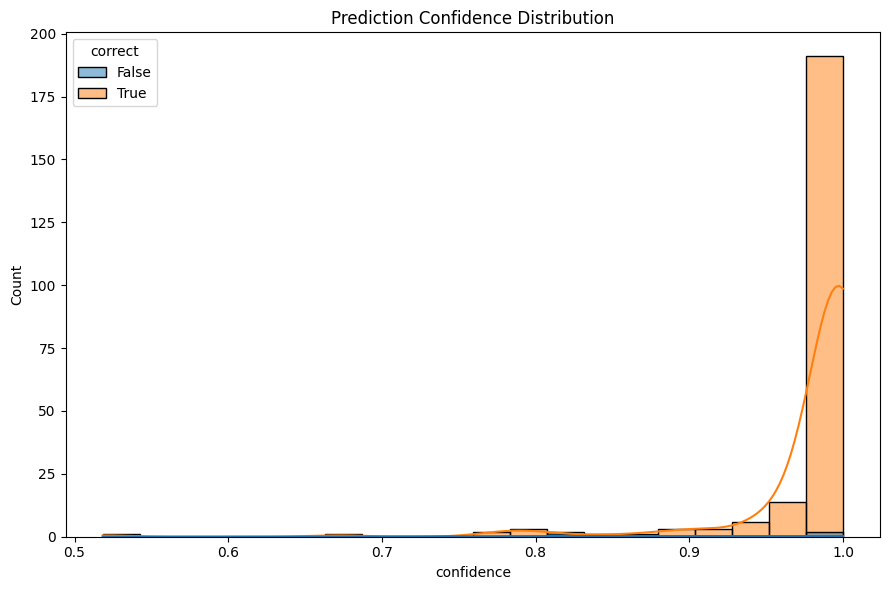

In [36]:
confidence_scores = np.max(probabilities, axis=1)

confidence_df = pd.DataFrame({
    "confidence": confidence_scores,
    "correct": true_labels == predicted_labels
})

plt.figure(figsize=(9, 6))

sns.histplot(
    data=confidence_df,
    x="confidence",
    hue="correct",
    bins=20,
    kde=True
)

plt.title("Prediction Confidence Distribution")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confidence_distribution.png", dpi=300)
plt.show()


## Save All Results

In [37]:
prediction_df = test_df.copy()

prediction_df["true_class"] = [CLASS_NAMES[x] for x in true_labels]
prediction_df["predicted_class"] = [CLASS_NAMES[x] for x in predicted_labels]
prediction_df["confidence"] = confidence_scores

for i, class_name in enumerate(CLASS_NAMES):
    prediction_df[f"probability_{class_name}"] = probabilities[:, i]

prediction_df.to_csv(f"{OUTPUT_DIR}/test_predictions.csv", index=False)

features_df.to_csv(f"{OUTPUT_DIR}/engineered_features.csv", index=False)
feature_scores.to_csv(f"{OUTPUT_DIR}/feature_selection_scores.csv", index=False)

model.save(f"{OUTPUT_DIR}/final_diabetic_retinopathy_model.keras")

print("Results saved to:", OUTPUT_DIR)


Results saved to: /content/diabetic_retinopathy_outputs


## Single-Image Prediction

In [39]:
def predict_single_image(image_path, trained_model=model):

    image = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))

    image_array = img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    probabilities = trained_model.predict(image_array, verbose=0)[0]

    predicted_index = np.argmax(probabilities)
    predicted_class = CLASS_NAMES[predicted_index]
    confidence = probabilities[predicted_index]

    print("Prediction:", predicted_class)
    print(f"Confidence: {confidence * 100:.2f}%")

    print("\nClass probabilities:")
    for i, class_name in enumerate(CLASS_NAMES):
        print(f"{class_name}: {probabilities[i] * 100:.2f}%")

    plt.figure(figsize=(6, 6))
    plt.imshow(Image.open(image_path).convert("RGB"))
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence * 100:.2f}%")
    plt.axis("off")
    plt.show()

    return predicted_class, confidence, probabilities



Prediction: DR
Confidence: 99.93%

Class probabilities:
DR: 99.93%
No_DR: 0.07%


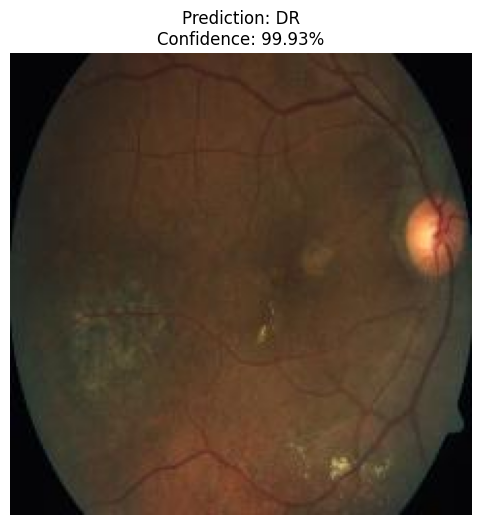

('DR',
 np.float32(0.99925655),
 array([9.9925655e-01, 7.4339390e-04], dtype=float32))

In [40]:
TEST_IMAGE = test_df.iloc[0]["filepath"]
predict_single_image(TEST_IMAGE)


Prediction: DR
Confidence: 100.00%

Class probabilities:
DR: 100.00%
No_DR: 0.00%


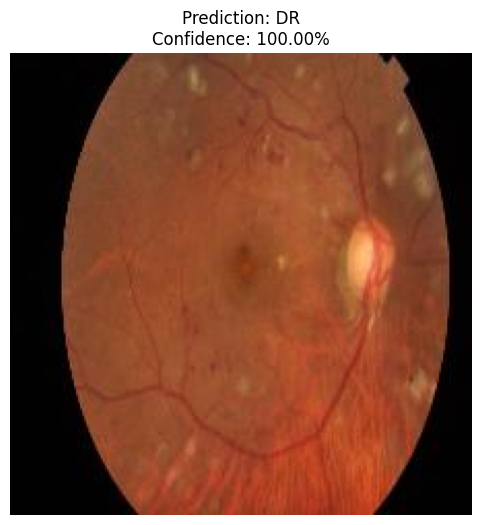

('DR',
 np.float32(0.9999945),
 array([9.9999452e-01, 5.4670704e-06], dtype=float32))

In [41]:
TEST_IMAGE = test_df.iloc[1]["filepath"]
predict_single_image(TEST_IMAGE)

Prediction: No_DR
Confidence: 99.98%

Class probabilities:
DR: 0.02%
No_DR: 99.98%


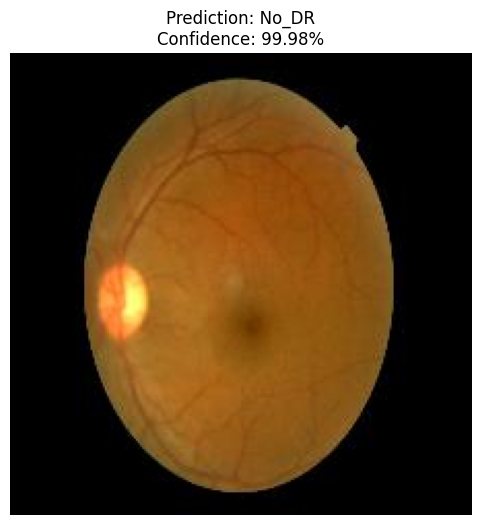

('No_DR',
 np.float32(0.99975413),
 array([2.4581086e-04, 9.9975413e-01], dtype=float32))

In [46]:
TEST_IMAGE = test_df.iloc[115]["filepath"]
predict_single_image(TEST_IMAGE)


Prediction: No_DR
Confidence: 98.94%

Class probabilities:
DR: 1.06%
No_DR: 98.94%


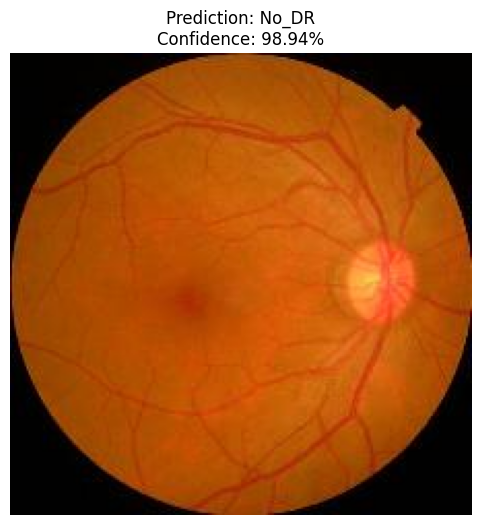

('No_DR',
 np.float32(0.98940736),
 array([0.01059265, 0.98940736], dtype=float32))

In [47]:
misclassified_sample = errors_df.iloc[0]["filepath"] if len(errors_df) > 0 else test_df.iloc[2]["filepath"]
predict_single_image(misclassified_sample)


## Save Model

In [48]:
import os

os.makedirs("models", exist_ok=True)

model.save("models/diabetic_retinopathy_model.keras")

print("Model saved successfully!")


Model saved successfully!


In [49]:
_, preprocess_function = get_backbone(BACKBONE_NAME)

custom_objects = {
    'preprocess_input': preprocess_function
}

model = tf.keras.models.load_model("models/diabetic_retinopathy_model.keras", custom_objects=custom_objects)


In [50]:
from google.colab import files

files.download('models/diabetic_retinopathy_model.keras')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>